In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [2]:
housing = fetch_california_housing(as_frame=True)

df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
X = df.drop("MedHouseVal", axis=1)

y = df["MedHouseVal"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [6]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr.coef_
})

print(coefficients)

print("\nIntercept:", lr.intercept_)

      Feature  Coefficient
0      MedInc     0.448675
1    HouseAge     0.009724
2    AveRooms    -0.123323
3   AveBedrms     0.783145
4  Population    -0.000002
5    AveOccup    -0.003526
6    Latitude    -0.419792
7   Longitude    -0.433708

Intercept: -37.02327770606409


In [7]:
y_pred = lr.predict(X_test)

In [8]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE :", mse)
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

MSE : 0.5558915986952444
RMSE: 0.7455813830127764
MAE : 0.5332001304956553
R²  : 0.5757877060324508


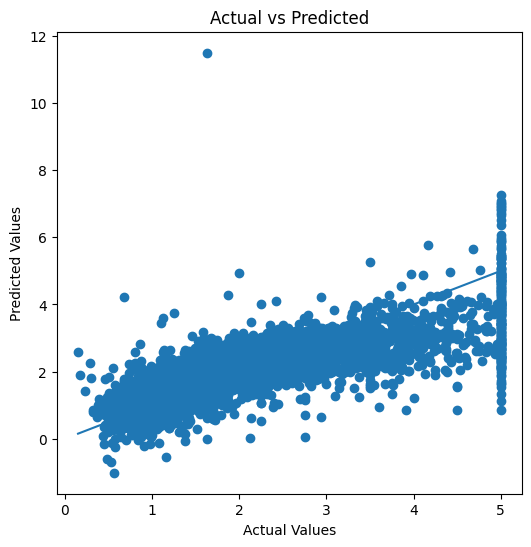

In [9]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

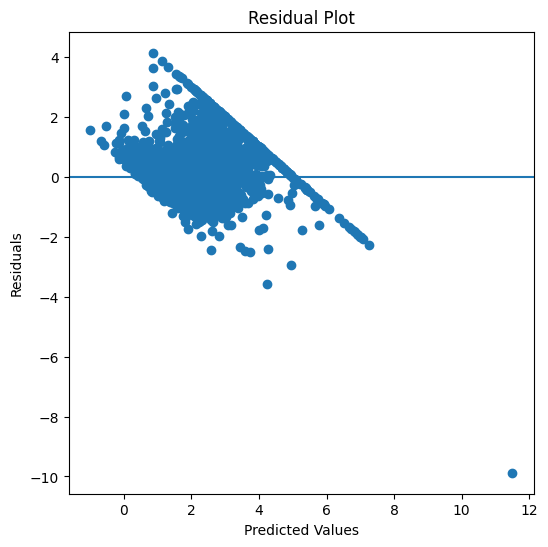

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(6,6))

plt.scatter(y_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [11]:
ridge = Ridge(alpha=1.0)

ridge.fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)

In [12]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

lasso_pred = lasso.predict(X_test)

In [13]:
def evaluate_model(name, actual, predicted):

    mse = mean_squared_error(actual, predicted)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(actual, predicted)
    r2 = r2_score(actual, predicted)

    return [name, mse, rmse, mae, r2]

In [14]:
results = []

results.append(evaluate_model(
    "Linear Regression",
    y_test,
    y_pred
))

results.append(evaluate_model(
    "Ridge",
    y_test,
    ridge_pred
))

results.append(evaluate_model(
    "Lasso",
    y_test,
    lasso_pred
))

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MSE",
        "RMSE",
        "MAE",
        "R2 Score"
    ]
)

results_df

,Model,MSE,RMSE,MAE,R2 Score
0,Linear Regression,0.555892,0.745581,0.533200,0.575788
1,Ridge,0.555803,0.745522,0.533204,0.575855
2,Lasso,0.613512,0.783270,0.581607,0.531817


In [15]:
results_df.to_csv("model_comparison.csv", index=False)

print("Results saved.")

Results saved.
